# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [16]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

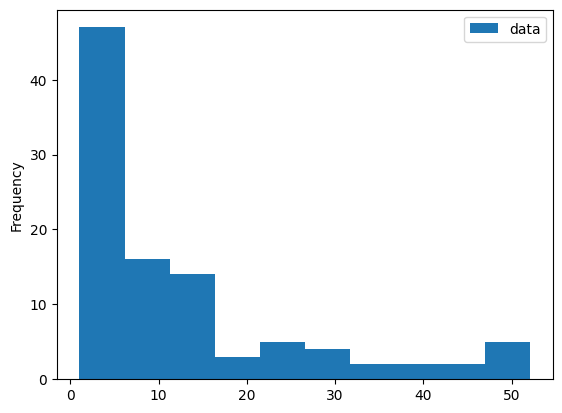

In [17]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

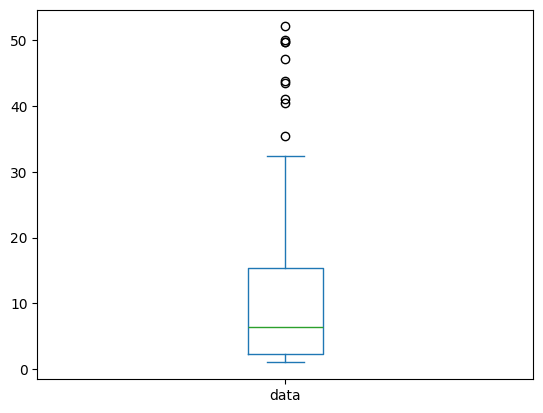

In [18]:
df.plot.box()

**Answer:**

The histogram shows the overall distribution of the prices of drugs, which does clearly reveal a strong right skew. This is showing many lower-priced drugs and a much less long-tail expensive drugs.

While the boxplot does show this too, with most of the outliers coming out of the high cost drugs - it is not as apparent from a visualization perspective.

Because the administrator is looking to understand how much more the expensive drugs are, I would choose the** histogram** because it shows the actual distribution of the prices.

**For improved formatting:**

*   List the axis labels
*   Shrink the width of the bars
*   Display the data labels to show actual % of total
*   Show some text that explains the overall distribution



# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# try:
#     from google.colab import drive  # Colab only
#     drive.mount('/content/drive')
# except ModuleNotFoundError:
#     # not running in Colab; skip
#     pass

# For Google Drive to Collab connection


df = pd.read_csv("Zillow_Data.csv")


date_cols = [c for c in df.columns if c[:4].isdigit()]
print("Rows, Cols:", df.shape)
print("First date:", date_cols[0], "Last date:", date_cols[-1])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows, Cols: (895, 317)
First date: 2000-01-31 Last date: 2025-12-31


In [20]:
latest = date_cols[-1]
one_year_ago = date_cols[-13]
baseline = date_cols[0]

df_feat = df.copy()
df_feat["value_latest"] = df_feat[latest]
df_feat["value_yoy_pct"] = (df_feat[latest] / df_feat[one_year_ago] - 1) * 100
df_feat["value_since2000_pct"] = (df_feat[latest] / df_feat[baseline] - 1) * 100


df_feat = df_feat[df_feat["value_latest"].notna()].copy()

df_feat[["value_latest","value_yoy_pct","value_since2000_pct"]].describe()

,value_latest,value_yoy_pct,value_since2000_pct
count,8.950000e+02,895.000000,431.000000
mean,2.868946e+05,1.264803,181.707725
std,1.724850e+05,3.829151,69.596112
min,4.348185e+04,-28.562377,35.947461
25%,1.828006e+05,-0.780273,131.188714
50%,2.419336e+05,1.614365,172.799295
75%,3.377599e+05,3.676071,222.160411
max,1.543938e+06,13.349950,542.844835


In [21]:
def plot_hist_variants(s, title):
    s = s.dropna()


    plt.figure()
    plt.hist(s, bins=30)
    plt.title(f"Histogram: {title}")
    plt.xlabel(title)
    plt.ylabel("Count")
    plt.show()


    plt.figure()
    plt.hist(s, bins=30, density=True)
    plt.title(f"Histogram (Density): {title}")
    plt.xlabel(title)
    plt.ylabel("Density")
    plt.show()


    plt.figure()
    s.plot(kind="kde")
    plt.title(f"KDE: {title}")
    plt.xlabel(title)
    plt.show()


    if (s > 0).all():
        plt.figure()
        plt.hist(np.log10(s), bins=30)
        plt.title(f"Histogram of log10({title})")
        plt.xlabel(f"log10({title})")
        plt.ylabel("Count")
        plt.show()

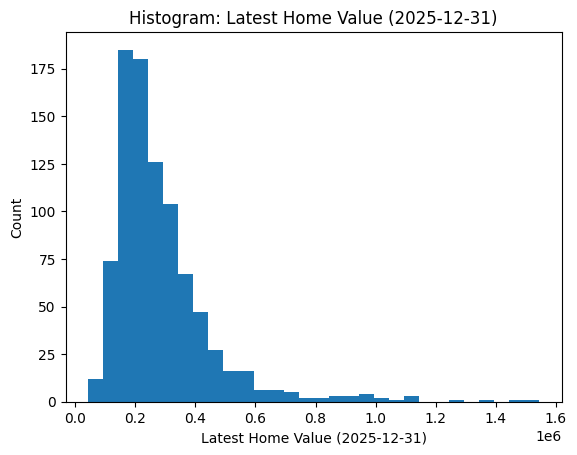

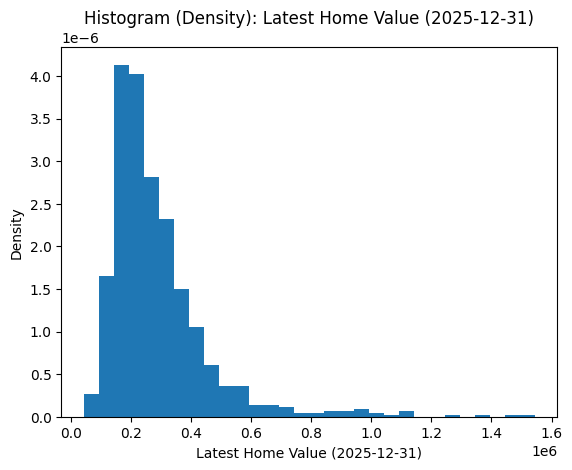

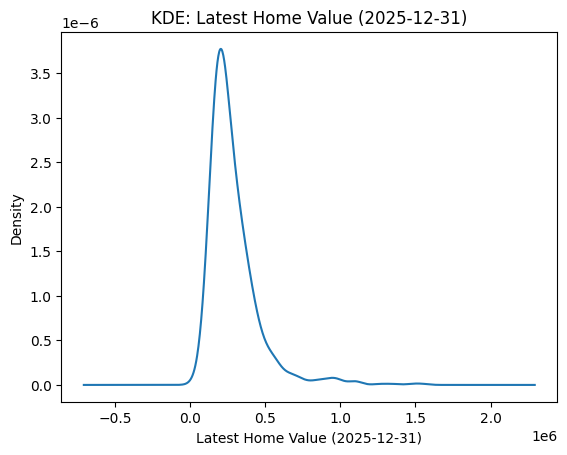

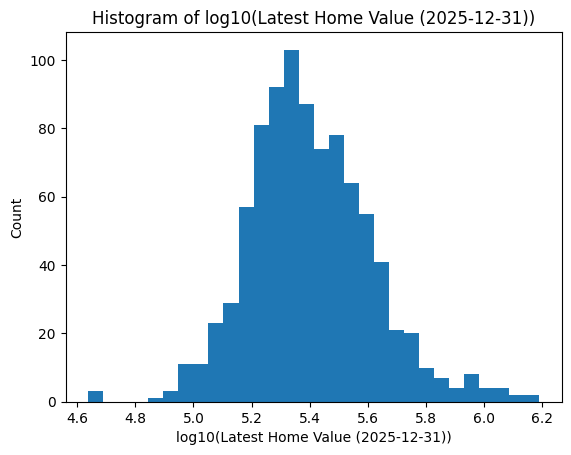

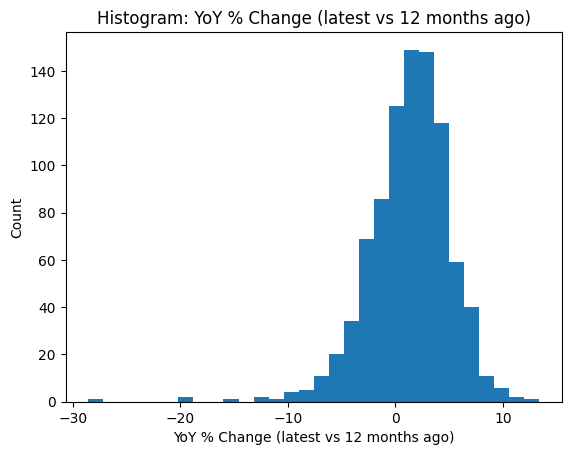

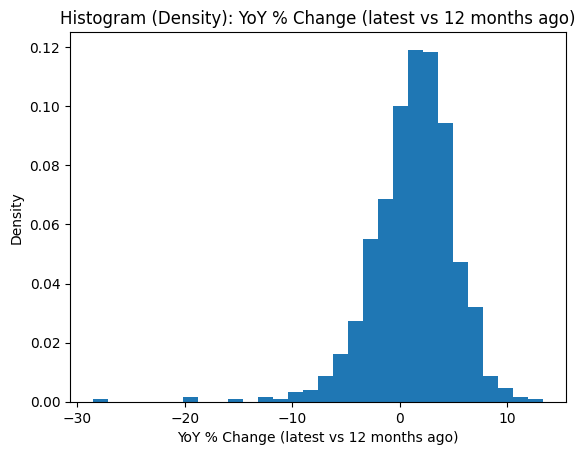

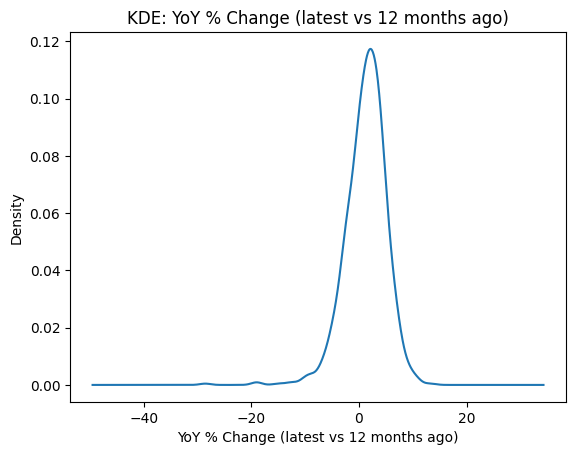

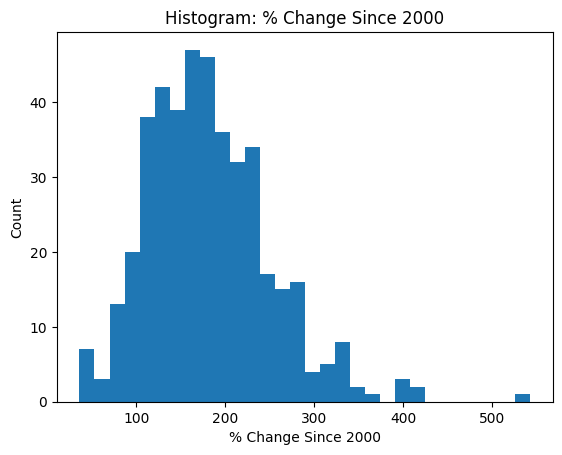

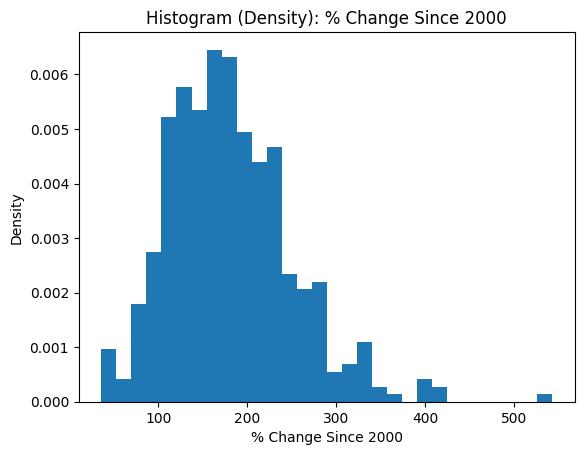

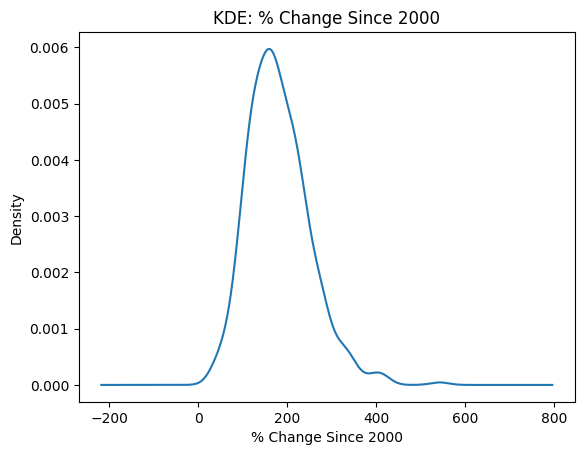

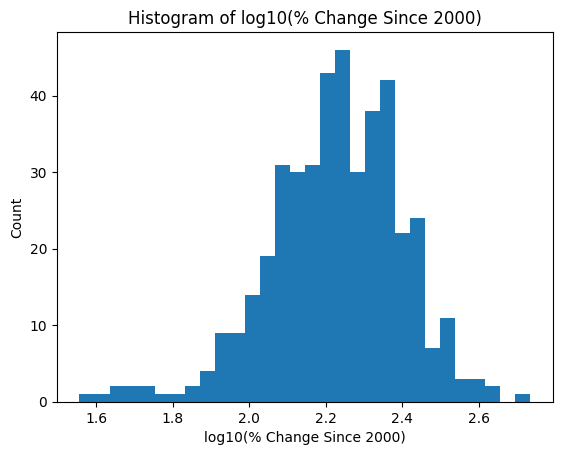

In [22]:
plot_hist_variants(df_feat["value_latest"], "Latest Home Value (2025-12-31)")
plot_hist_variants(df_feat["value_yoy_pct"], "YoY % Change (latest vs 12 months ago)")
plot_hist_variants(df_feat["value_since2000_pct"], "% Change Since 2000")

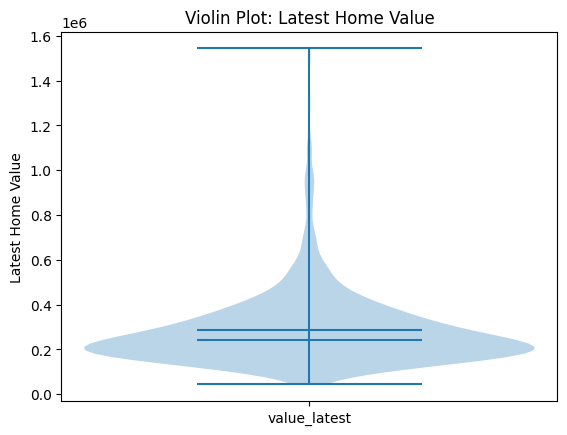

In [23]:
s = df_feat["value_latest"].dropna()

plt.figure()
plt.violinplot(s, showmeans=True, showmedians=True)
plt.title("Violin Plot: Latest Home Value")
plt.ylabel("Latest Home Value")
plt.xticks([1], ["value_latest"])
plt.show()

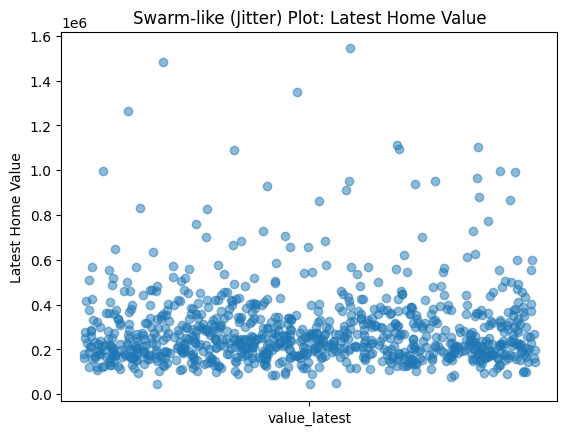

In [24]:
s = df_feat["value_latest"].dropna().values
x = 1 + np.random.uniform(-0.08, 0.08, size=len(s))

plt.figure()
plt.scatter(x, s, alpha=0.5)
plt.title("Swarm-like (Jitter) Plot: Latest Home Value")
plt.xticks([1], ["value_latest"])
plt.ylabel("Latest Home Value")
plt.show()

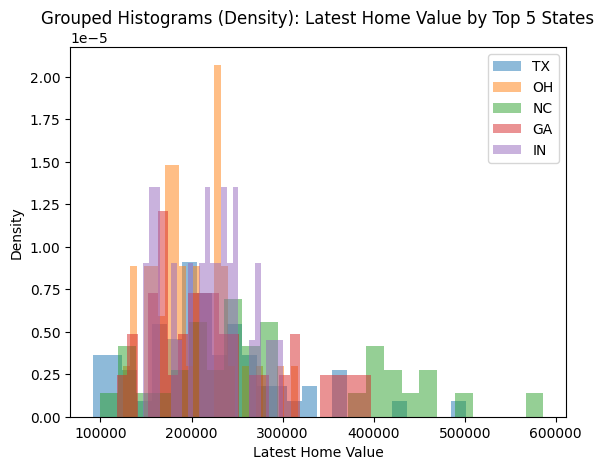

In [25]:
top_states = df_feat["StateName"].value_counts().head(5).index.tolist()
plt.figure()

for st in top_states:
    vals = df_feat.loc[df_feat["StateName"] == st, "value_latest"].dropna()
    plt.hist(vals, bins=25, alpha=0.5, density=True, label=st)

plt.title("Grouped Histograms (Density): Latest Home Value by Top 5 States")
plt.xlabel("Latest Home Value")
plt.ylabel("Density")
plt.legend()
plt.show()

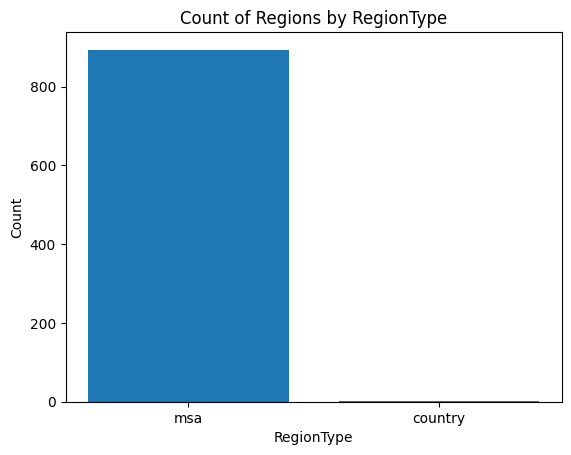

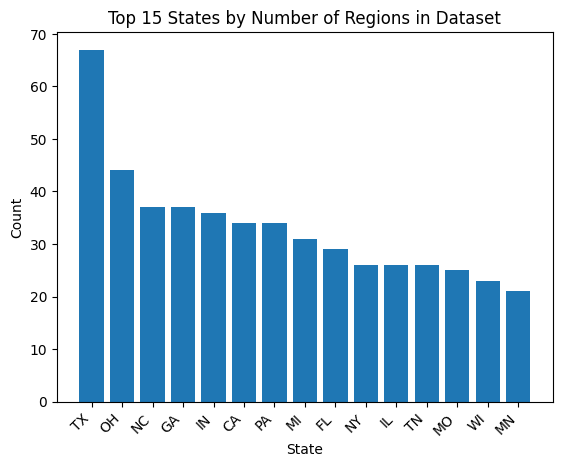

In [26]:
rt_counts = df["RegionType"].value_counts()

plt.figure()
plt.bar(rt_counts.index.astype(str), rt_counts.values)
plt.title("Count of Regions by RegionType")
plt.xlabel("RegionType")
plt.ylabel("Count")
plt.show()

state_counts = df_feat["StateName"].value_counts().head(15)

plt.figure()
plt.bar(state_counts.index.astype(str), state_counts.values)
plt.title("Top 15 States by Number of Regions in Dataset")
plt.xlabel("State")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

In [27]:
s = df_feat["value_latest"].dropna()

mean_val = s.mean()
median_val = s.median()

mode_rounded = s.round(0).mode()

q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr

skew = s.skew()

print("Latest Home Value summary")
print("Mean:", mean_val)
print("Median:", median_val)
print("Rounded mode(s):", mode_rounded.tolist())
print("Min:", s.min(), "Max:", s.max())
print("Q1:", q1, "Q3:", q3, "IQR:", iqr)
print("Skewness:", skew)
print("High outliers (IQR rule):", (s > upper).sum())


outliers = df_feat.loc[df_feat["value_latest"] > upper, ["RegionName","StateName","value_latest"]].sort_values("value_latest", ascending=False)
outliers.head(10)

Latest Home Value summary
Mean: 286894.6168329607
Median: 241933.64325263983
Rounded mode(s): [164841.0, 199038.0]
Min: 43481.85434564782 Max: 1543938.4765838727
Q1: 182800.55057770753 Q3: 337759.92566188565 IQR: 154959.37508417811
Skewness: 2.7951786937454393
High outliers (IQR rule): 45


,RegionName,StateName,value_latest
35,"San Jose, CA",CA,1.543938e+06
871,"Vineyard Haven, MA",MA,1.480956e+06
744,"Jackson, WY",WY,1.348734e+06
549,"Edwards, CO",CO,1.265188e+06
454,"Heber, UT",UT,1.111192e+06
179,"Santa Cruz, CA",CA,1.102781e+06
12,"San Francisco, CA",CA,1.094164e+06
832,"Steamboat Springs, CO",CO,1.088518e+06
465,"Kapaa, HI",HI,9.974222e+05
831,"Hailey, ID",ID,9.969624e+05


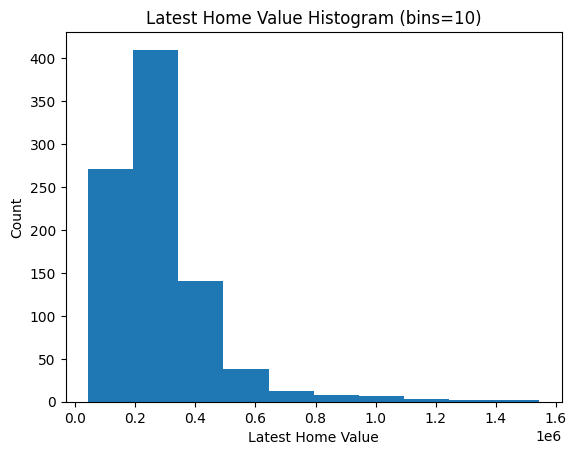

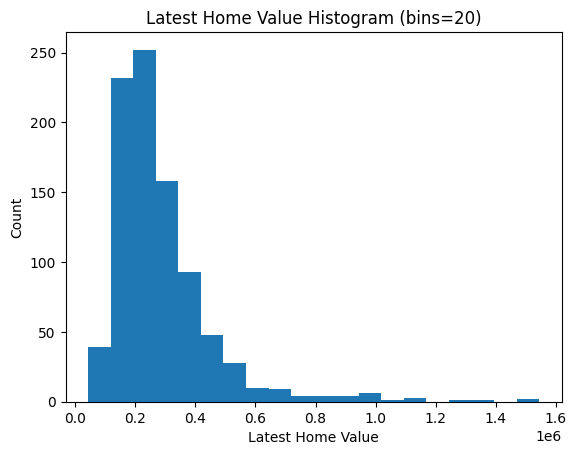

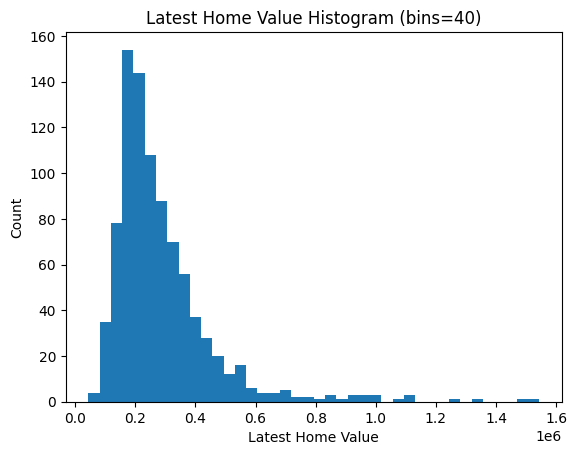

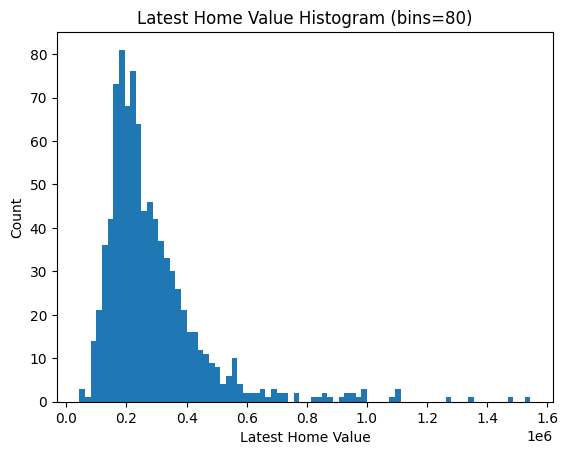

In [28]:
s = df_feat["value_latest"].dropna()

for bins in [10, 20, 40, 80]:
    plt.figure()
    plt.hist(s, bins=bins)
    plt.title(f"Latest Home Value Histogram (bins={bins})")
    plt.xlabel("Latest Home Value")
    plt.ylabel("Count")
    plt.show()

**Overview:**

This data set contains around ~895 regions of geography, and monthly Zillow home estimates from January 2000 through December 2025. I created a small set opf numerical features to analyze univariately:


1.   Lastest Home Value
2.   YoY % Change
3. % Changes from 2000

**The Univeriate Distribution - Latest Home Value**

This distribution of the latest home value is significantly right-skewed. Most regions cluster to the lower-min price range, while a smaller number of regions have extremely high values.


*   Mean: **$286K**

*   Median: **$241K**

*   75th Percentile: **$337K**

*   Max: **$1.5M**

Most noteablem the mean is higher than the median whichh does align with the right skew that is driven by large outliers. Our skewness is high (2.8), which quanitfies this conclusion.

**Outliers:**

Using the 1.5 x IQR method, there were 45 outliers identified (no meaningful low outliers because values are bounded near zero). The most extreme regions include very high-cost markets (e.g., San Jose CA, Vineyard Haven MA, Jackson WY), which align with real-world expectations for expensive housing markets.

**Yoy Change:**

The YoY % change feature tends to be much more centered than raw values, while the “since 2000” growth feature typically remains right-skewed (growth compounding over 25 years). These features provide interpretable measures of market movement beyond absolute price levels.

**Group Differences: **

The grouped histograms provided by state reveals that distributiosn between states differ quite a bit. Some states have higher centers and wider spreads.

Categorical Distributions:
A bar plot of the RegionType indicates that the data set is showing MSAs, which mweans Metro-level pricing rather than the city / neighboprhood details.

**Bin Size:**

Changing the histrogram bin sizes counts does affect how bumpy the data is. With less bins, the strucutre becomems oversiumplified. And with more bines, it becommes too bumpy. So a medium group of 25-40 was used.

**Conclusion on Usability:**

Overall, the data look usable and consistent with expectations: strong right-skew in home values, sensible high-end outliers, and meaningful geographic variation. The main practical limitation is the wide time-series format, so feature engineering (latest value, growth rates) is **useful for clear univariate analysis.**

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

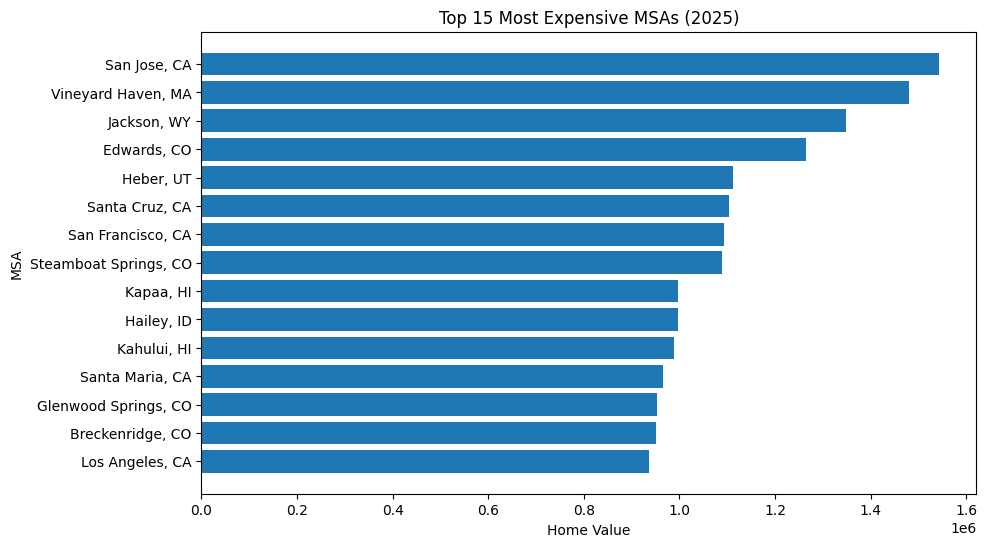

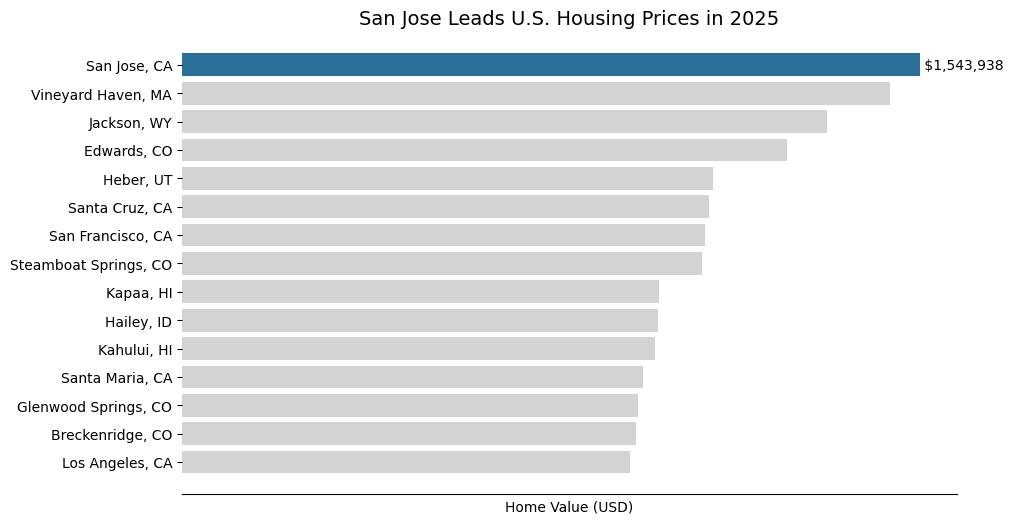

In [29]:
df = pd.read_csv("/content/drive/MyDrive/Zillow_Data.csv")

date_cols = [c for c in df.columns if c[:4].isdigit()]
latest = date_cols[-1]

df["value_latest"] = df[latest]
df = df[df["value_latest"].notna()]

# Sort and take top 15
top15 = df.sort_values("value_latest", ascending=False).head(15).copy()
top15 = top15.sort_values("value_latest")  # sort for horizontal bar

plt.figure(figsize=(10,6))
plt.barh(top15["RegionName"], top15["value_latest"])
plt.title("Top 15 Most Expensive MSAs (2025)")
plt.xlabel("Home Value")
plt.ylabel("MSA")
plt.show()

plt.figure(figsize=(10,6))

colors = ["lightgray"] * len(top15)
colors[-1] = "#2a6f97"  # highlight highest value

plt.barh(top15["RegionName"], top15["value_latest"], color=colors)

plt.title("San Jose Leads U.S. Housing Prices in 2025", fontsize=14)

plt.xlabel("Home Value (USD)")
plt.xticks([])
plt.ylabel("")

# Remove extra chart junk
for spine in ["top","right","left"]:
    plt.gca().spines[spine].set_visible(False)

# Annotate highlight
highlight_value = top15["value_latest"].iloc[-1]
highlight_region = top15["RegionName"].iloc[-1]

plt.text(highlight_value,
         highlight_region,
         f" ${highlight_value:,.0f}",
         va="center")

plt.show()

**Write Up:**

This assignment was a chart inspired by the Storytelling With Data Chapter 2 visualizations. In general, this book was emphasizing the reduction of clutter and keeping attention clear.

I first created a standard horizontal bar chart of the top 15 most expensive metropolitan areas in 2025. While accurate, the initial version did not clearly guide the viewers attention.

I then redesigned the chart using storytelling principles:

*   Removed unnecessary gridlines and spines
*   Eliminated distracting axis ticks
*   Used muted gray bars for context
*   Highlighted the most expensive region in blue
*   Added direct labeling instead of relying on axes

The revised chart communicates a clear message: San Jose has the highest housing values among major U.S. metro areas in 2025. By visually emphasizing one bar, the viewer immediately understands the key takeaway without scanning the entire chart.